## Objective

The objective of this notebook is to identify the best forecasting model for deployment.

Unlike Notebook 01, which evaluates feature engineering under controlled conditions, this notebook focuses solely on maximizing forecasting accuracy through hyperparameter optimization.

Each model is allowed to use the feature version that produces its best performance.

## Imports

In [7]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

from pathlib import Path

import joblib
import warnings

import optuna

warnings.filterwarnings("ignore")

## Configuration

In [8]:
DB_PATH = "../gridsight.duckdb"

TRAIN_END_DATE = "2025-12-31 23:00:00"
TEST_START_DATE = "2026-01-01 00:00:00"
TEST_END_DATE = "2026-06-30 23:00:00"

TARGET = "solar_generation_mw"

RANDOM_STATE = 42

EXPERIMENTS_DIR = Path("../experiments")
MODELS_DIR = Path("../models")

EXPERIMENTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## Load Gold Dataset

In [9]:
with duckdb.connect(DB_PATH) as con:
    df = con.sql("""
        SELECT *
        FROM gold_training_dataset
        ORDER BY timestamp
    """).df()

## Train/Test Split

In [10]:
train_df = df[df['timestamp'] < TEST_START_DATE]
train_df

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
0,2023-01-08 00:00:00,2.207500,5.572,81.16,0.040,94.56,19.008,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,105.912576,0.0
1,2023-01-08 01:00:00,2.052500,5.336,80.92,0.004,89.76,19.436,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,103.710496,0.0
2,2023-01-08 02:00:00,1.962500,5.596,82.72,0.008,93.88,19.540,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,109.345840,0.0
3,2023-01-08 03:00:00,2.322500,5.260,83.48,0.084,94.12,19.656,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,103.390560,0.0
4,2023-01-08 04:00:00,2.310000,5.216,83.40,0.100,89.72,19.308,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,100.710528,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26131,2025-12-31 19:00:00,16.194653,-0.380,84.84,0.084,79.84,16.532,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,579,1.0,0.0,-0.0,-6.282160,0.0
26132,2025-12-31 20:00:00,12.068738,-0.412,86.56,0.096,83.88,15.920,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,639,1.0,0.0,-0.0,-6.559040,0.0
26133,2025-12-31 21:00:00,13.948841,-0.472,87.32,0.072,80.84,16.024,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,699,1.0,0.0,-0.0,-7.563328,0.0
26134,2025-12-31 22:00:00,12.549746,-0.528,87.88,0.052,83.60,16.384,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,759,1.0,0.0,-0.0,-8.650752,0.0


In [11]:
test_df = df[df['timestamp'] >= TEST_START_DATE]
test_df

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
26136,2026-01-01 00:00:00,15.137830,-0.568,87.12,0.048,83.36,17.780,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-10.099040,0.000000
26137,2026-01-01 01:00:00,15.056636,-0.504,86.52,0.036,84.36,18.340,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-9.243360,0.000000
26138,2026-01-01 02:00:00,16.133698,-0.584,86.04,0.076,79.88,18.592,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-10.857728,0.000000
26139,2026-01-01 03:00:00,12.625848,-0.556,86.32,0.088,83.28,20.048,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-11.146688,0.000000
26140,2026-01-01 04:00:00,12.553904,-0.576,85.76,0.024,82.20,20.524,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-11.821824,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2026-06-30 16:00:00,12288.627500,24.156,53.84,0.092,70.72,8.232,615.72,412.08,203.64,...,42819.561250,16.504208,15.619033,1,654,0.660438,43543.7184,14873.33232,198.852192,406.644649
29996,2026-06-30 17:00:00,5923.406750,23.940,54.28,0.064,73.36,8.340,499.72,306.48,193.24,...,42819.561250,16.504208,15.619033,1,714,0.721028,36659.4592,11963.29680,199.659600,360.312223
29997,2026-06-30 18:00:00,1910.517250,23.440,56.96,0.280,71.40,8.860,364.12,196.20,167.92,...,42819.561250,16.504208,15.619033,1,774,0.781619,25998.1680,8534.97280,207.678400,284.603048
29998,2026-06-30 19:00:00,173.456500,23.008,59.20,0.052,67.16,8.240,249.68,122.96,126.72,...,42819.561250,16.504208,15.619033,1,834,0.842209,16768.5088,5744.63744,189.585920,210.282852


## Features

### v0 Features

In [12]:
v0_features = [
    "solar_generation_mw_lag_1h",
    "solar_generation_mw_lag_24h",
    "solar_generation_mw_lag_168h"
]

### v1 Features

In [13]:
v1_features = v0_features + [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "cloud_cover_pct",
    "wind_speed_kmh",
    
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance"
]

### v2 Features

In [14]:
v2_features = v1_features + [
  "hour",
  "month",
  "day_of_week",
  "day_of_year",
  "is_weekend",
  "year"
]

### v3 Features

In [15]:
v3_features = v2_features + [
  "daylight_duration_hours",
  "sunshine_duration_hours",
  "is_daylight",
  "minutes_since_sunrise",
  "daylight_progress_pct",
]

### v4 Features

In [16]:
v4_features = v3_features + [
  "solar_generation_mw_roll_mean_3h",
  "solar_generation_mw_roll_mean_6h",
  "solar_generation_mw_roll_mean_24h",
  
  "solar_generation_mw_roll_std_3h",
  "solar_generation_mw_roll_std_6h",
  "solar_generation_mw_roll_std_24h",
  
  "solar_generation_mw_roll_min_3h",
  "solar_generation_mw_roll_min_6h",
  "solar_generation_mw_roll_min_24h",
  
  "solar_generation_mw_roll_max_3h",
  "solar_generation_mw_roll_max_6h",
  "solar_generation_mw_roll_max_24h"
]

### v5 Features

In [17]:
v5_features = v4_features + [
  "cloud_shortwave_interaction",
  "temperature_shortwave_interaction",
  "wind_temperature_interaction",
  "daylight_progress_shortwave_interaction"
]

In [18]:
feature_versions = {
  "V0": v0_features,
  "V1": v1_features,
  "V2": v2_features,
  "V3": v3_features,
  "V4": v4_features,
  "V5": v5_features
}

## Baseline Features

## Baseline Model Performance

Baseline experiments were conducted using default model hyperparameters to evaluate the impact of incremental feature engineering across feature versions (V0–V5). These results establish a reference point before hyperparameter optimization.

| Model | Best Feature Version | Baseline WAPE (%) | Notes |
|------|----------------------|------------------:|-------|
| Linear Regression | V5 | **8.31** | Best overall baseline model |
| XGBoost | V2 | **24.43** | Best baseline among feature versions |
| LightGBM | V2 | **24.98** | Best baseline among feature versions |

Hyperparameter optimization is performed in the following sections to determine whether tuning can further improve forecasting performance beyond these baseline results.

## XGBoost Hyperparameter Optimization

The objective of this section is to identify the optimal combination of feature version and hyperparameters for XGBoost.

Unlike the controlled experiments in Notebook 01, this optimization prioritizes forecasting accuracy. Each feature version (V0–V5) is independently optimized using Optuna, allowing both the feature representation and hyperparameters to vary. The feature version achieving the lowest WAPE is selected as the production configuration for XGBoost.

### Training Data

In [48]:
xgb_optimization_results = []

for version, features in feature_versions.items():

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]
    
    # OBJECTIVE FUNCTION
    
    def objective(trial):

        learning_rate = trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        )

        max_depth = trial.suggest_int(
            "max_depth",
            2,
            8
        )
        
        n_estimators = trial.suggest_int(
            "n_estimators",
            100,
            1000
        )
        
        subsample = trial.suggest_float(
            "subsample",
            0.6,
            1.0
        )
        
        colsample_bytree = trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        )
        
        
        model = XGBRegressor(
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0
    )
        
        model.fit(X_train, y_train)
        
        predictions = model.predict(X_test)
        
        wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100
        
        return wape
    
    
    study = optuna.create_study(
    direction="minimize"
)

    study.optimize(
    objective,
    n_trials=150
)
    
    xgb_optimization_results.append({
        "Version": version,
        "Best WAPE": study.best_value,
        "Best Params": study.best_params
    })
    
        


[I 2026-07-13 13:32:20,429] A new study created in memory with name: no-name-1252b2fc-97ed-4171-9ace-b059fcb6ce38
[I 2026-07-13 13:32:20,560] Trial 0 finished with value: 38.524033771303614 and parameters: {'learning_rate': 0.17703465047890674, 'max_depth': 2, 'n_estimators': 171, 'subsample': 0.8392687565399057, 'colsample_bytree': 0.9828884512078881}. Best is trial 0 with value: 38.524033771303614.
[I 2026-07-13 13:32:20,822] Trial 1 finished with value: 32.56508544832733 and parameters: {'learning_rate': 0.23320943868465274, 'max_depth': 2, 'n_estimators': 378, 'subsample': 0.7790584552285182, 'colsample_bytree': 0.8431756610817619}. Best is trial 1 with value: 32.56508544832733.
[I 2026-07-13 13:32:22,079] Trial 2 finished with value: 43.15329221921216 and parameters: {'learning_rate': 0.29320148475627067, 'max_depth': 7, 'n_estimators': 663, 'subsample': 0.6101333245659486, 'colsample_bytree': 0.6145904363320053}. Best is trial 1 with value: 32.56508544832733.
[I 2026-07-13 13:32:

### Run Optuna

In [49]:
results_df = pd.DataFrame(xgb_optimization_results)
results_df = results_df.sort_values("Best WAPE")
results_df

,Version,Best WAPE,Best Params
3,V3,10.477030,"{'learning_rate': 0.2836535638476923, 'max_dep..."
2,V2,10.939404,"{'learning_rate': 0.28831674281824593, 'max_de..."
4,V4,12.863604,"{'learning_rate': 0.27900020095485417, 'max_de..."
5,V5,15.731079,"{'learning_rate': 0.18412594484677056, 'max_de..."
1,V1,19.905930,"{'learning_rate': 0.24125419053249358, 'max_de..."
0,V0,28.744847,"{'learning_rate': 0.1844995451834629, 'max_dep..."


### Best Parameters

In [51]:
best_result = results_df.iloc[0]

best_version = best_result["Version"]
best_wape = best_result["Best WAPE"]
best_params = best_result["Best Params"]

In [52]:
print(best_version)
print(best_wape)
print(best_params)

V3
10.477030148162667
{'learning_rate': 0.2836535638476923, 'max_depth': 3, 'n_estimators': 955, 'subsample': 0.99907535930191, 'colsample_bytree': 0.8889593670524224}


### Final Model Train

In [61]:
best_features = feature_versions[best_version]

X_train = train_df[best_features]
y_train = train_df[TARGET]

X_test = test_df[best_features]
y_test = test_df[TARGET]

final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    verbosity=0
)

final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)

In [62]:
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100

In [63]:
print(f"Best Feature Version: {best_version}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WAPE: {wape:.2f}%")

Best Feature Version: V3
MAE: 1171.96
RMSE: 2180.44
WAPE: 10.48%


### Save Model

In [69]:
joblib.dump(final_model, "models/xgboost_v3_optuna.joblib")

['models/xgboost_v3_optuna.joblib']

### Prediction Plot

In [60]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Predicted
26136,15.137830,0.000000
26137,15.056636,0.000000
26138,16.133698,0.000000
26139,12.625848,0.000000
26140,12.553904,0.000000
26141,12.576750,0.000000
26142,16.808553,59.618736
26143,454.760703,431.052643
26144,3061.433624,2270.049561
26145,5952.409014,5972.915527


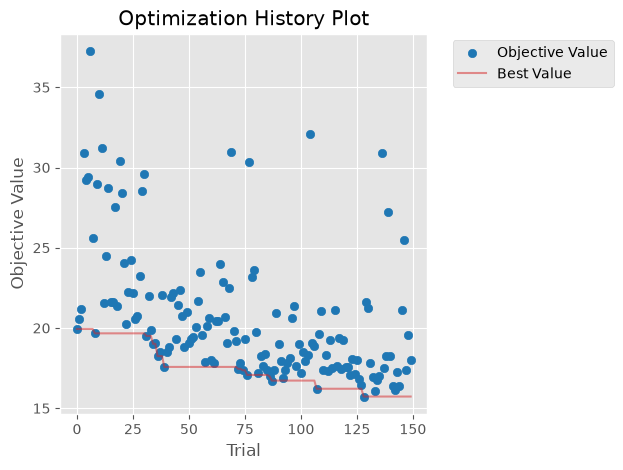

In [70]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

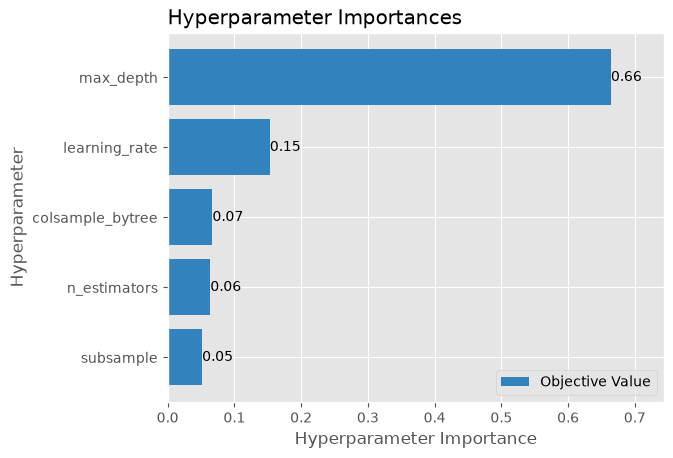

In [71]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

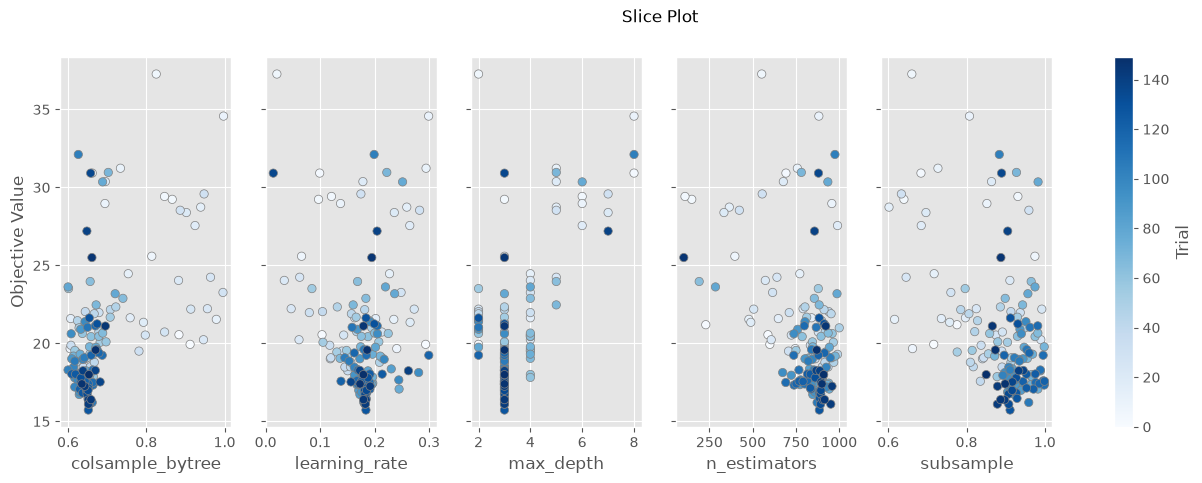

In [75]:
optuna.visualization.matplotlib.plot_slice(study)
plt.show()

### XGBoost Optimization Summary

| Parameter | Value |
|-----------|-------|
| Optimization Library | Optuna |
| Optimization Trials | 150 |
| Objective Metric | WAPE |
| Best Feature Version | **V3** |
| Best WAPE | **10.48%** |
| Best Hyperparameter | **Maximum Tree Depth (`max_depth`)** |

### Best Hyperparameters

| Hyperparameter | Optimal Value |
|---------------|--------------:|
| Learning Rate | 0.2837 |
| Maximum Depth | 3 |
| Number of Trees | 955 |
| Subsample | 0.9991 |
| Column Sample by Tree | 0.8890 |

## LightGBM Hyperparameter Optimization

## Production Model Comparison

## Final Production Model

## Save Production Model

## Discussion